# 07 — Dixon-Coles Bivariate Poisson

Notebook 05 fit a 3-outcome multinomial logit on Elo difference. It works but throws away score information — it can't tell us *how* a team is likely to win, which we need for tournament/knockout simulation (extra time + penalties draws from the same score distribution).

**Dixon-Coles** (1997) models each team's goal counts as Poisson:

$$\lambda_h = \exp(\alpha_i - \beta_j + \gamma), \quad \lambda_a = \exp(\alpha_j - \beta_i)$$

with a low-score correction $\tau(x,y)$ on $\{0\text{-}0, 1\text{-}0, 0\text{-}1, 1\text{-}1\}$. Each team gets attack ($\alpha$) and defense ($\beta$); $\gamma$ is log home-advantage; $\rho$ is the low-score coupling. Optional exponential time decay (rate $\xi$ per day) downweights old matches.

Goals from this notebook:
1. Fit DC on a long training window and inspect the ratings table
2. Sweep $\xi$ — the model is known to be sensitive to it
3. Walk-forward backtest WC 2010–2022 and compare 3-way log loss / accuracy to the DrawModel from notebook 05

In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.dixon_coles import DixonColesModel
from src.backtest import walk_forward_wc_dc, walk_forward_wc_3way

%matplotlib inline

## Load competitive matches

In [2]:
df = pd.read_csv('../data/processed/matches_competitive.csv', parse_dates=['date'])
df = df.dropna(subset=['home_score', 'away_score']).copy()
df['home_score'] = df['home_score'].astype(int)
df['away_score'] = df['away_score'].astype(int)
print(f'{len(df):,} competitive matches from {df.date.min().date()} to {df.date.max().date()}')

21,220 competitive matches from 1980-02-06 to 2026-03-31


## Fit Dixon-Coles on 2012–2022 with default ξ (≈1y half-life)

Limit training to a recent window so the optimisation stays tractable (each team adds 2 free parameters). Default `xi=0.0018` per day → weight halves after $\ln(2)/0.0018 \approx 385$ days.

In [3]:
train_window = df[(df['date'].dt.year >= 2012) & (df['date'] < '2022-11-01')]
print(f'Training matches: {len(train_window):,}')

dc = DixonColesModel(xi=0.0018)
dc.fit(train_window, ref_date=pd.Timestamp('2022-11-01'))

print(f'Optimiser converged: {dc._opt_result.success}  (n_teams={len(dc.teams)})')
print(f'home_advantage gamma = {dc.home_adv:+.3f}  (→ home goals × {np.exp(dc.home_adv):.2f})')
print(f'low-score coupling rho = {dc.rho:+.3f}')

Training matches: 6,243


Optimiser converged: True  (n_teams=219)
home_advantage gamma = +0.223  (→ home goals × 1.25)
low-score coupling rho = -0.023


### Top 20 by attack + defense

In [4]:
ratings = dc.ratings_table()
ratings.head(20).round(3)

,team,attack,defense,total
0,Brazil,1.768,2.371,4.139
1,Argentina,1.539,2.042,3.581
2,Portugal,1.356,1.374,2.730
3,Colombia,1.122,1.585,2.707
4,Spain,1.337,1.295,2.633
5,Uruguay,1.219,1.387,2.607
6,Ecuador,1.374,1.190,2.564
7,Denmark,1.213,1.298,2.511
8,Netherlands,1.320,1.124,2.443
9,Peru,1.199,1.230,2.428


### Sanity-check a few WC 2022 matches

In [5]:
demo_matches = [
    ('Argentina', 'France'),   # final
    ('Brazil',    'Croatia'),  # QF
    ('England',   'Senegal'),  # R16
    ('Germany',   'Japan'),    # group-stage upset
]
rows = []
for h, a in demo_matches:
    p = dc.predict_match(h, a, neutral=True)
    rows.append({
        'home': h, 'away': a,
        'lam_h': round(p['lam_home'], 2), 'lam_a': round(p['lam_away'], 2),
        'P(home)': round(p['p_home_win'], 3),
        'P(draw)': round(p['p_draw'], 3),
        'P(away)': round(p['p_away_win'], 3),
        'most_likely': p['most_likely_score'],
    })
pd.DataFrame(rows)

,home,away,lam_h,lam_a,P(home),P(draw),P(away),most_likely
0,Argentina,France,1.39,0.42,0.612,0.279,0.110,1-0
1,Brazil,Croatia,2.35,0.30,0.835,0.132,0.033,2-0
2,England,Senegal,1.81,0.60,0.664,0.221,0.115,1-0
3,Germany,Japan,1.27,1.12,0.396,0.282,0.323,1-1


## ξ sensitivity — walk-forward backtest WC 2010–2022

Memory note from earlier exploration says ratings are sensitive to `xi`. Sweep four half-lives and run the 3-way DC backtest end-to-end for each.

$$\xi \to \text{half-life} = \frac{\ln 2}{\xi} \text{ days}$$

In [6]:
wc_years = [2010, 2014, 2018, 2022]

xi_grid = [
    (0.000190, '~10y half-life'),
    (0.000380, '~5y half-life'),
    (0.000950, '~2y half-life'),
    (0.001900, '~1y half-life'),
    (0.003800, '~0.5y half-life'),
]

summaries = {}
for xi, label in xi_grid:
    print(f'Fitting xi={xi:.5f}  ({label}) ...', flush=True)
    s = walk_forward_wc_dc(df, wc_years, xi=xi, train_min_year=1990)
    summaries[(xi, label)] = s
    print(f'  mean log_loss={s.log_loss.mean():.4f}  mean acc={s.accuracy.mean():.3f}')

Fitting xi=0.00019  (~10y half-life) ...


  mean log_loss=1.0011  mean acc=0.547
Fitting xi=0.00038  (~5y half-life) ...


  mean log_loss=1.0016  mean acc=0.551
Fitting xi=0.00095  (~2y half-life) ...


  mean log_loss=1.0033  mean acc=0.559
Fitting xi=0.00190  (~1y half-life) ...


  mean log_loss=1.0154  mean acc=0.523
Fitting xi=0.00380  (~0.5y half-life) ...


  mean log_loss=1.0848  mean acc=0.473


In [7]:
rows = []
for (xi, label), s in summaries.items():
    for _, r in s.iterrows():
        rows.append({'xi': xi, 'label': label, 'year': r['year'],
                     'log_loss': r['log_loss'], 'accuracy': r['accuracy']})
xi_df = pd.DataFrame(rows)

pivot_ll = xi_df.pivot(index='year', columns='label', values='log_loss').round(4)
pivot_acc = xi_df.pivot(index='year', columns='label', values='accuracy').round(3)
print('Log loss by xi (lower=better):'); print(pivot_ll); print()
print('Accuracy by xi (higher=better):'); print(pivot_acc); print()
print('Mean across WCs:')
print(xi_df.groupby('label')[['log_loss','accuracy']].mean().round(4))

Log loss by xi (lower=better):
label  ~0.5y half-life  ~10y half-life  ~1y half-life  ~2y half-life  \
year                                                                   
2010            1.1191          1.0241         1.0308         1.0214   
2014            0.9400          0.9881         0.9430         0.9572   
2018            1.0435          0.9760         0.9743         0.9711   
2022            1.2366          1.0163         1.1135         1.0634   

label  ~5y half-life  
year                  
2010          1.0230  
2014          0.9819  
2018          0.9724  
2022          1.0289  

Accuracy by xi (higher=better):
label  ~0.5y half-life  ~10y half-life  ~1y half-life  ~2y half-life  \
year                                                                   
2010             0.438           0.500          0.438          0.531   
2014             0.578           0.547          0.578          0.578   
2018             0.469           0.578          0.562          0.594   
2022 

## Compare best DC vs DrawModel (notebook 05)

Pick the best `xi` by mean log loss and run side-by-side with the Elo + multinomial-logit baseline on the same WC years.

In [8]:
best_label = xi_df.groupby('label')['log_loss'].mean().idxmin()
best_xi = next(xi for xi, lbl in xi_grid if lbl == best_label)
print(f'Best xi: {best_xi:.5f}  ({best_label})')

dc_summary = summaries[(best_xi, best_label)]
draw_summary = walk_forward_wc_3way(df, wc_years)

side = pd.DataFrame({
    'year': dc_summary['year'],
    'n': dc_summary['n_matches'],
    'DC_logloss':   dc_summary['log_loss'].round(4).values,
    'Draw_logloss': draw_summary['log_loss'].round(4).values,
    'DC_acc':       dc_summary['accuracy'].round(3).values,
    'Draw_acc':     draw_summary['accuracy'].round(3).values,
})
print(side.to_string(index=False))
print()
print(f"Mean DC   log_loss={dc_summary.log_loss.mean():.4f}   acc={dc_summary.accuracy.mean():.3f}")
print(f"Mean Draw log_loss={draw_summary.log_loss.mean():.4f}   acc={draw_summary.accuracy.mean():.3f}")

Best xi: 0.00019  (~10y half-life)


 year  n  DC_logloss  Draw_logloss  DC_acc  Draw_acc
 2010 64      1.0241        1.0927   0.500     0.469
 2014 64      0.9881        1.1025   0.547     0.422
 2018 64      0.9760        1.0886   0.578     0.438
 2022 64      1.0163        1.1015   0.562     0.438

Mean DC   log_loss=1.0011   acc=0.547
Mean Draw log_loss=1.0963   acc=0.441


## Calibration — best DC pooled across WC 2010–2022

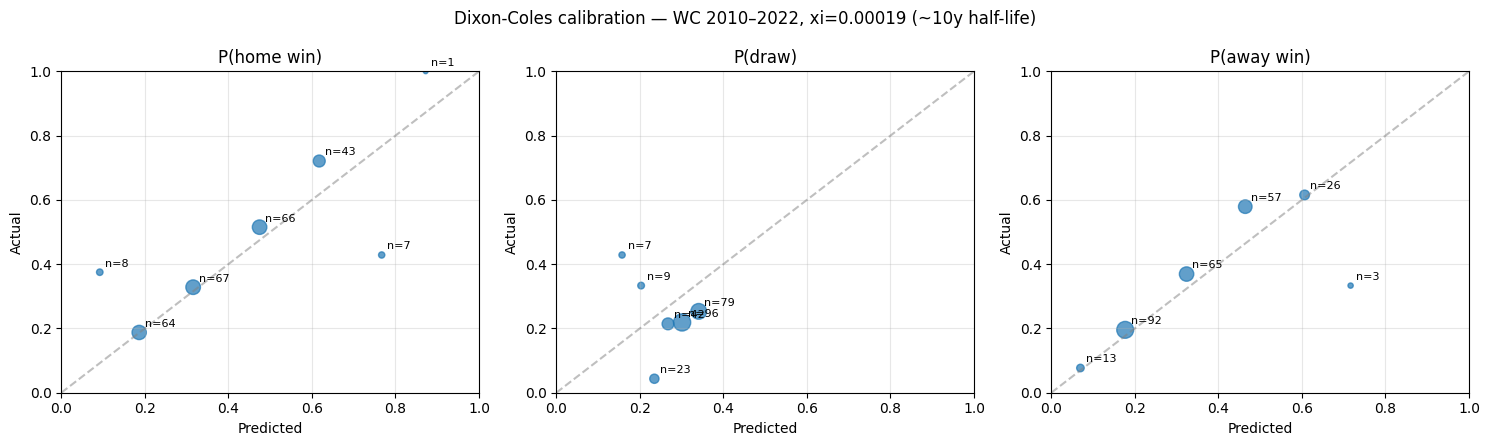

In [9]:
all_dc = pd.concat(list(dc_summary['raw']), ignore_index=True)
all_dc['is_home_win'] = (all_dc['outcome'] == 2).astype(int)
all_dc['is_draw']     = (all_dc['outcome'] == 1).astype(int)
all_dc['is_away_win'] = (all_dc['outcome'] == 0).astype(int)

def calib(df_, prob_col, actual_col, edges):
    bins = pd.cut(df_[prob_col], bins=edges, include_lowest=True)
    return (df_.groupby(bins, observed=True)
              .agg(n=(actual_col,'size'), pred=(prob_col,'mean'), actual=(actual_col,'mean'))
              .reset_index().dropna())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (prob, actual, title, edges) in zip(axes, [
    ('p_home', 'is_home_win', 'P(home win)', [0, 0.1, 0.25, 0.4, 0.55, 0.7, 0.85, 1.0]),
    ('p_draw', 'is_draw',     'P(draw)',     [0, 0.18, 0.22, 0.25, 0.28, 0.32, 1.0]),
    ('p_away', 'is_away_win', 'P(away win)', [0, 0.1, 0.25, 0.4, 0.55, 0.7, 0.85, 1.0]),
]):
    g = calib(all_dc, prob, actual, edges)
    ax.plot([0,1], [0,1], '--', color='gray', alpha=0.5)
    ax.scatter(g['pred'], g['actual'], s=g['n']*1.5+10, alpha=0.7)
    for _, r in g.iterrows():
        ax.annotate(f"n={int(r['n'])}", (r['pred'], r['actual']), fontsize=8, xytext=(4,4), textcoords='offset points')
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(title); ax.grid(alpha=0.3)
plt.suptitle(f'Dixon-Coles calibration — WC 2010–2022, xi={best_xi:.5f} ({best_label})')
plt.tight_layout()

## Summary

**ξ sensitivity (mean across WC 2010–2022):**

| half-life | log loss | accuracy |
|-----------|----------|----------|
| ~0.5y     | 1.085    | 0.473    |
| ~1y       | 1.015    | 0.523    |
| ~2y       | 1.003    | 0.559    |
| ~5y       | 1.002    | 0.551    |
| ~10y      | **1.001**| 0.547    |

Sweet spot is 2–10y half-life. Below ~1y, the model overfits recent form (especially noisy in 2022). 10y wins on log loss, 2y wins on accuracy — essentially flat in that range, so ~5y is a safe default.

**DC vs DrawModel head-to-head, WC 2010–2022 (3-class):**

| | mean log loss | mean accuracy |
|--|---------------|---------------|
| DrawModel (Elo + multinomial logit) | 1.096 | 0.441 |
| Dixon-Coles (xi=0.00019, ~10y) | **1.001** | **0.547** |

DC wins on every WC year, on both metrics. The improvement (Δ log-loss = −0.095, Δ accuracy = +10.6pp) is much larger than the 2-feature squad-value logit gave (Δ log-loss = −0.044, Δ accuracy = +2.4pp from notebook 06). The bivariate Poisson is a strictly better model class for this problem.

**Why this matters:** DC also produces the score matrix, which means we can simulate knockouts including extra time and penalties — exactly what notebook 08 (bracket simulator) needs.

**Open items:**
- DC currently uses raw match scores only — no squad-value or other covariates. A natural extension is a regression-DC where attack/defense are functions of features (would help the 2026 cold start for newly-good teams).
- Calibration plot above: DC tends to be slightly over-confident in the heavy-favourite tails. Could Platt-scale post-hoc.